In [5]:
%matplotlib widget
import scipp as sc
import tof

source = tof.Source(facility="ess", neutrons=1_000_000)
da = source.data.squeeze()
da.hist(birth_time=200, wavelength=500).plot(
    cmap="jet",
    xmin=sc.scalar(0, unit="Å"),
    xmax=sc.scalar(5, unit="Å"),
    grid=True,
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

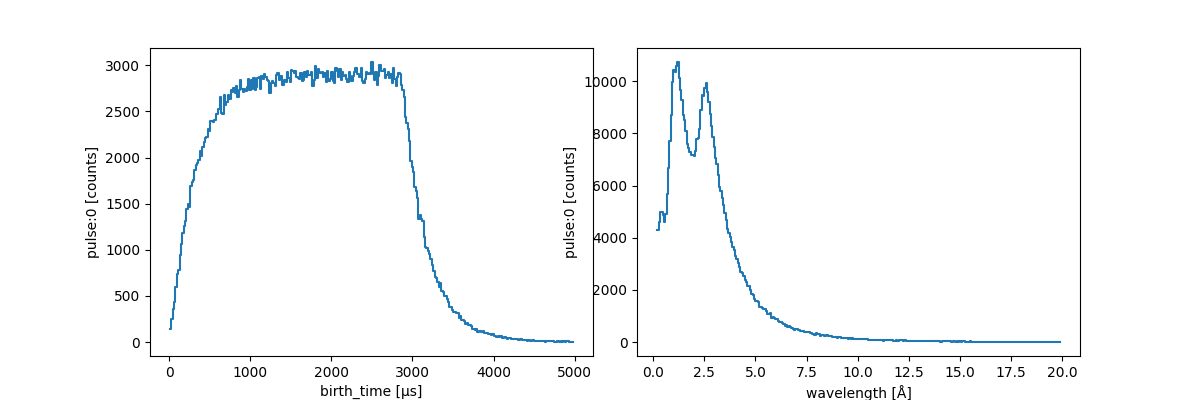

In [6]:
source = tof.Source(facility="ess", neutrons=500_000)
source.plot()

In [7]:
import scipp as sc
from trex.source import Source
from trex.instrument import Instrument

central_wavelength = sc.scalar(2.5, unit="Å")
rrm: int = 8  # repetition rate multiplication factor
T_OFFSET = sc.scalar(1.7, unit="ms")
trex = Instrument(wavelength=central_wavelength, rrm=rrm, t_offset=T_OFFSET)
mask = trex.mask_from_chopper("Monochromatic Chopper 2")
# mask = trex.mask_from_chopper("Bandwidth Chopper 2")

source = Source(facility="ess", neutrons=1_000_000)
source.apply_mask(mask)
print(source.data)

<scipp.DataArray>
Dimensions: Sizes[pulse:1, event:3755, ]
Coordinates:
* birth_time                float64            [µs]  (pulse, event)  [795.915, 1502.65, ..., 1823.78, 2513.39]
* distance                  float64              [m]  ()  0
* eto                       float64            [µs]  (pulse, event)  [795.915, 1502.65, ..., 1823.78, 2513.39]
* id                          int64        <no unit>  (pulse, event)  [78, 133, ..., 999907, 999993]
* speed                     float64            [m/s]  (pulse, event)  [1443.49, 1912.26, ..., 1585.07, 1465.52]
* toa                       float64            [µs]  (pulse, event)  [795.915, 1502.65, ..., 1823.78, 2513.39]
* wavelength                float64             [Å]  (pulse, event)  [2.7406, 2.06877, ..., 2.49581, 2.6994]
Data:
                            float64         [counts]  (pulse, event)  [1, 1, ..., 1, 1]




In [8]:
da = source.data.squeeze()
da.hist(birth_time=100, wavelength=100).plot(
    cmap="jet",
    xmin=sc.scalar(1.5, unit="Å"),
    xmax=sc.scalar(3.5, unit="Å"),
    grid=True,
    ymin=sc.scalar(0.0, unit="ms"),
    ymax=sc.scalar(4, unit="ms"),
)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…